# PJ14 — AI 분석 결과 인사이트 리포트

> **입력**: `output/topic_4_articles_ai_분석결과.csv`
> **목적**: 성남시 주거/교통 문제 구조 파악 → PJ15 주제 확정

| 셀 | 내용 |
|---|---|
| 0 | 데이터 로드 & 기본 정제 |
| 1 | 문제 유형 분포 (전체 + 시계열) |
| 2 | 세부 주제 그룹핑 |
| 3 | 이해관계자 네트워크 |
| 4 | 핵심 인사이트 요약 |
| 5 | PJ15 주제 확정 |

In [7]:
# ─── 셀 0: 데이터 로드 & 기본 정제 ─────────────────────────────────────────

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

_THIS_DIR  = Path(globals().get("__vsc_ipynb_file__", ".")).parent
_pj14      = _THIS_DIR if (_THIS_DIR / "output").exists() else Path("01_Daily_Project/PJ14_Sungnam_News_Crawling")
OUTPUT_DIR = (_pj14 / "output").resolve()

# ▼ 분석할 AI 분석결과 CSV ▼
TARGET_CSV = OUTPUT_DIR / "topic_1_articles_ai_분석결과.csv"

df = pd.read_csv(TARGET_CSV, encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], format="%Y.%m.%d.", errors="coerce")
df["month"] = df["date"].dt.to_period("M")

# 분석실패 행 분리
df_ok   = df[df["세부_주제"] != "분석실패"].copy()
df_fail = df[df["세부_주제"] == "분석실패"]

print(f"전체: {len(df)}건  |  분석성공: {len(df_ok)}건  |  실패: {len(df_fail)}건")
print(f"기간: {df['date'].min().date()} ~ {df['date'].max().date()}")
df_ok.head(3)

전체: 278건  |  분석성공: 278건  |  실패: 0건
기간: 2024-04-05 ~ 2026-03-03


,title,press,date,link,세부_주제,관련_이해관계자,문제_유형,한_줄_요약,month
0,"김병욱 ""제 기반 잡아준 분당... 은혜 갚기 위해 최선 다하겠다""",오마이뉴스,2024-04-05,https://n.news.naver.com/mnews/article/047/000...,분당 1기 신도시 재건축 사업 추진 및 지역 현안 해결,"김병욱 후보(더불어민주당), 분당 주민, 성남시청",주거/부동산,김병욱 후보가 분당 1기 신도시 재건축 신속 추진 및 지역 경제 활성화를 공약하며 ...,2024-04
1,성남 은행주공 또 시공사 계약해지 추진,파이낸셜뉴스,2024-04-08,https://n.news.naver.com/mnews/article/014/000...,은행주공 재건축 공사비 갈등에 따른 시공사 계약해지 추진,"은행주공 재건축 조합, GS건설·HDC현대산업개발 컨소시엄",주거/부동산,성남 은행주공 재건축 조합이 공사비 증액 갈등으로 시공사 계약해지를 다시 추진한다.,2024-04
2,공사비 갈등에…신탁방식 재건축도 '빨간불',한국경제,2024-04-08,https://n.news.naver.com/mnews/article/015/000...,공사비 상승에 따른 신탁방식 재건축 사업 차질,"부동산신탁사, 재건축 조합 및 주민, 성남시청",주거/부동산,공사비 상승과 업황 악화로 신탁사들이 선별 수주에 나서며 신탁방식 재건축 사업이 지...,2024-04


In [12]:
df_ok['문제_유형'].value_counts()

문제_유형
주거/부동산    205
교통         33
행정/정책      15
예산/재정       8
인프라/시설      7
복지/의료       5
안전          2
환경          2
기타          1
Name: count, dtype: int64

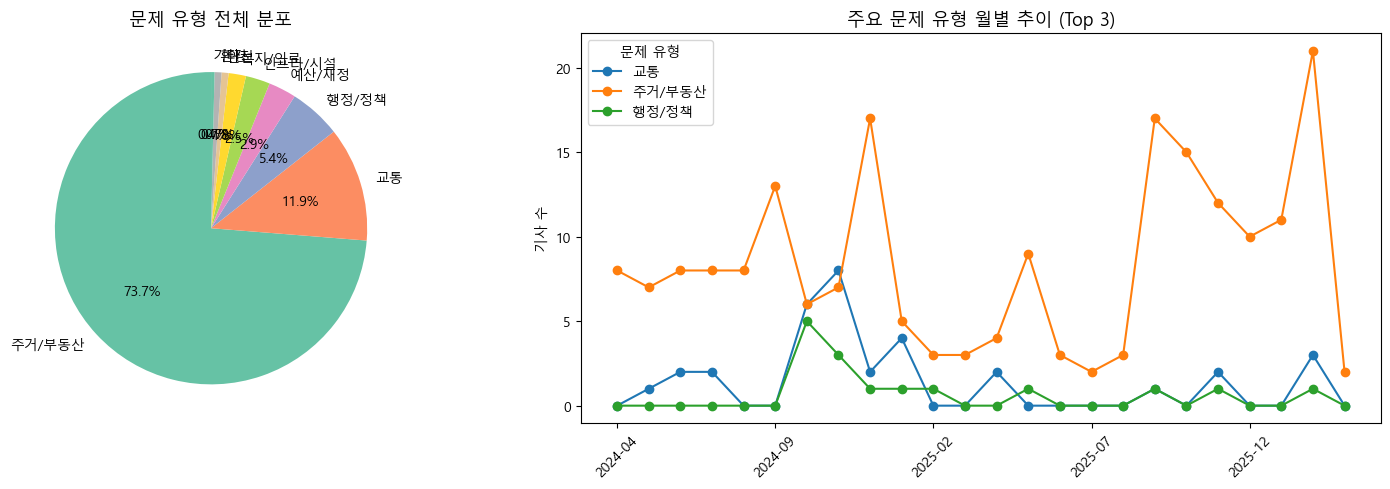

In [13]:
# ─── 셀 1: 문제 유형 분포 (전체 + 시계열) ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ① 전체 파이차트
type_counts = df_ok["문제_유형"].value_counts()
colors = plt.cm.Set2.colors[:len(type_counts)]
axes[0].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
            startangle=90, colors=colors)
axes[0].set_title("문제 유형 전체 분포", fontsize=13)

# ② 월별 유형 추이 (상위 3개 유형)
top3_types = type_counts.head(3).index.tolist()
monthly = (df_ok[df_ok["문제_유형"].isin(top3_types)]
           .groupby(["month", "문제_유형"])
           .size().unstack(fill_value=0))
monthly.index = monthly.index.astype(str)
monthly.plot(ax=axes[1], marker="o")
axes[1].set_title("주요 문제 유형 월별 추이 (Top 3)", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("기사 수")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="문제 유형")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "report_1_문제유형분포.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# 주거/부동산 세부 유형 분류
HOUSING_RULES = [
    ("재건축/선도지구", ["재건축", "선도지구", "정비", "재개발", "뉴타운"]),
    ("분양/청약",       ["분양", "청약", "입주", "분상제", "로또"]),
    ("부동산 시세",     ["매매", "상승", "하락", "집값", "패닉바잉", "시세"]),
    ("임대주택",        ["임대", "공공임대", "부영", "전세"]),
]

def assign_housing_group(subject: str) -> str:
    for label, keywords in HOUSING_RULES:
        if any(kw in str(subject) for kw in keywords):
            return label
    return "기타 주거"

df_housing = df_ok[df_ok["문제_유형"] == "주거/부동산"].copy()
df_housing["주거_세부유형"] = df_housing["세부_주제"].apply(assign_housing_group)

print(df_housing["주거_세부유형"].value_counts())


주거_세부유형
재건축/선도지구    108
기타 주거        54
부동산 시세       23
분양/청약        20
Name: count, dtype: int64


주제_그룹
재건축/선도지구    108
기타           84
부동산 시세       29
분양/청약        20
광역철도/교통망     19
도로/교통개선      10
재정/예산         5
복지/청년         2
임대주택          1
Name: count, dtype: int64


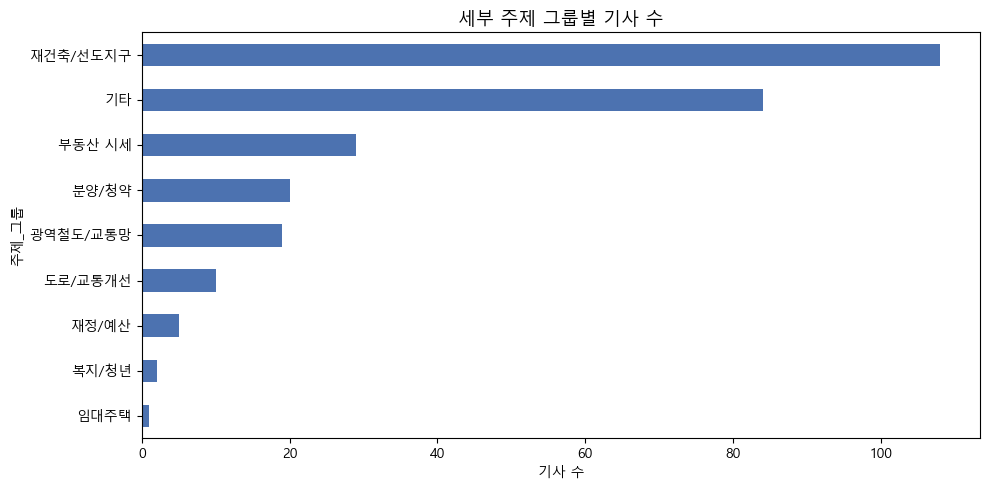

In [10]:
# ─── 셀 2: 세부 주제 그룹핑 ─────────────────────────────────────────────────
# 세부_주제 텍스트에서 핵심 키워드로 그룹 레이블 부여

GROUP_RULES = [
    ("재건축/선도지구",  ["재건축", "선도지구", "정비", "재개발"]),
    ("분양/청약",        ["분양", "청약", "입주", "분상제", "로또"]),
    ("임대주택",         ["임대", "공공임대", "전세", "부영"]),
    ("부동산 시세",      ["아파트", "매매", "상승", "하락", "집값", "패닉바잉"]),
    ("광역철도/교통망",  ["철도", "광역", "지하철", "GTX", "위례신사"]),
    ("도로/교통개선",    ["도로", "교통", "고속화", "교차로", "교량", "고기교"]),
    ("재정/예산",        ["재정", "예산", "지방세", "세수", "펑크"]),
    ("복지/청년",        ["복지", "청년", "기본소득", "의료"]),
]

def assign_group(subject: str) -> str:
    for label, keywords in GROUP_RULES:
        if any(kw in str(subject) for kw in keywords):
            return label
    return "기타"

df_ok["주제_그룹"] = df_ok["세부_주제"].apply(assign_group)

group_counts = df_ok["주제_그룹"].value_counts()
print(group_counts)

fig, ax = plt.subplots(figsize=(10, 5))
group_counts.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("세부 주제 그룹별 기사 수", fontsize=13)
ax.set_xlabel("기사 수")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "report_2_세부주제그룹.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ─── 셀 2-1: 기타 세부_주제 키워드 분석 ──────────────────────────────────────

from collections import Counter
import re

df_기타 = df_ok[df_ok["주제_그룹"] == "부동산 시세"]["세부_주제"]

# ① 세부_주제 전체 목록
print(f"【 기타 분류 기사: {len(df_기타)}건 】\n")
for s in df_기타.tolist():
    print(" -", s)

# ② 명사 단위 키워드 빈도 (2글자 이상 단어 기준)
print("\n\n【 기타 항목 키워드 빈도 Top 30 】\n")
words = []
for s in df_기타:
    words.extend(re.findall(r"[가-힣]{2,}", str(s)))

for word, cnt in Counter(words).most_common(30):
    print(f"  {word}: {cnt}회")


【 기타 분류 기사: 29건 】

 - 지방자치단체 재정자립도 하락 및 예산 부족 문제
 - 아파트 단지 내 외부인 출입 통제를 위한 펜스 설치 갈등
 - 강남 고가 아파트 신혼부부 특별공급의 현실적 실효성 논란
 - 10월 전국 경매시장 동향 및 분당 아파트 경매 사례
 - 위례신도시 교통망 확충 지연에 따른 부동산 가격 하락
 - 위례신도시 부동산 가격 하락 및 위례과천선 노선 갈등
 - 수도권 중대형 아파트 매매가격 상승 및 희소성 부각
 - 수도권 중대형 아파트 공급 부족에 따른 가격 상승 현상
 - 수도권 중대형 아파트 매매가 상승 및 희소성 부각
 - 수도권 및 성남시 분당·수정구 아파트 매매가 상승세 지속
 - 분당구 등 수도권 주요 지역 아파트값 상승세 및 풍선효과
 - 정부 고위직의 규제지역 부동산 보유 및 자산 가치 상승 논란
 - 규제 지역 내 아파트 경매 낙찰가율 상승 및 분당구 시장 과열
 - 서울·성남 등 아파트 경매 낙찰가율 상승 및 풍선효과
 - 10·15 부동산 대책 이후 성남시 분당구 아파트 매매가 상승세 둔화
 - 정부 부동산 대책 이후 수도권 아파트값 상승 및 풍선효과 지속
 - 강남·과천·분당 지식산업 삼각벨트 내 고가 주택 시장 상승세 및 공급 부족
 - 대출 규제에도 지속되는 성남시 분당구 아파트값 상승
 - 수도권 및 성남시 부동산 시장의 공급 부족에 따른 가격 상승 우려
 - 성남 분당구 아파트 경매 낙찰가율 상승 및 과열 현상
 - 오픈채팅방을 활용한 아파트 집값 담합 행위 적발 및 수사
 - 경기도 내 아파트 단지 집값 담합 행위 적발
 - 성남시 등 경기도 일대 아파트 집값 담합 행위 적발
 - 경기도 아파트 경매시장 과열 현상
 - 서울 인접 경기 지역 아파트 경매시장 풍선효과 및 가격 상승
 - 주택가격 상승 기대심리 변화 및 부동산 정책 방향
 - 서울 인접 경기 지역 30대 아파트 매수세 변화 및 성남시 거래 위축
 - 수도권 및 성남시 아파트 월세 가격 상승 현황
 - 아파트 대출 규제에 따른 오피스텔

전체 이해관계자: 395명  |  표시: 20명


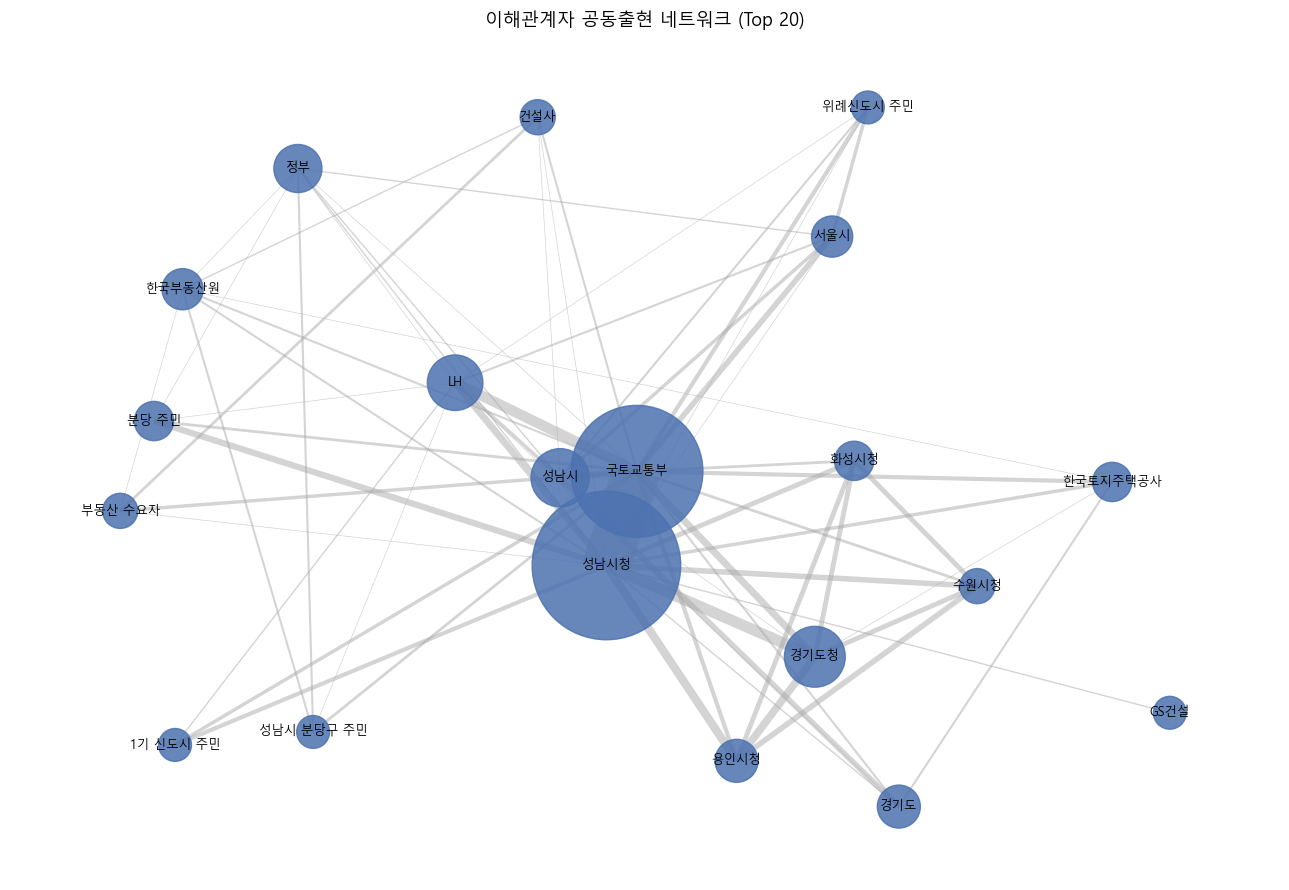

In [17]:
# ─── 셀 3: 이해관계자 네트워크 ──────────────────────────────────────────────

import networkx as nx
from itertools import combinations
import re

# 이해관계자 파싱: 쉼표/괄호 기준 분리
def parse_stakeholders(s):
    if not isinstance(s, str) or not s.strip():
        return []
    items = re.split(r"[,，]", s)
    cleaned = []
    for item in items:
        item = re.sub(r"\(.*?\)", "", item).strip()
        if len(item) >= 2:
            cleaned.append(item)
    return cleaned

df_ok["이해관계자_list"] = df_ok["관련_이해관계자"].apply(parse_stakeholders)

# 공동출현 엣지 생성
G = nx.Graph()
for stakeholders in df_ok["이해관계자_list"]:
    for a, b in combinations(stakeholders, 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)

# 상위 노드만 표시 (출현 빈도 기준)
from collections import Counter
all_nodes = [n for row in df_ok["이해관계자_list"] for n in row]
top_nodes = {n for n, _ in Counter(all_nodes).most_common(20)}
sub_G = G.subgraph(top_nodes)

print(f"전체 이해관계자: {G.number_of_nodes()}명  |  표시: {sub_G.number_of_nodes()}명")

fig, ax = plt.subplots(figsize=(13, 9))
pos = nx.spring_layout(sub_G, seed=42, k=2.5)
weights = [sub_G[u][v]["weight"] for u, v in sub_G.edges()]
node_sizes = [Counter(all_nodes)[n] * 80 for n in sub_G.nodes()]

nx.draw_networkx_edges(sub_G, pos, width=[w * 0.5 for w in weights],
                       alpha=0.5, edge_color="#aaa", ax=ax)
nx.draw_networkx_nodes(sub_G, pos, node_size=node_sizes,
                       node_color="#4C72B0", alpha=0.85, ax=ax)
nx.draw_networkx_labels(sub_G, pos, font_size=9,
                        font_family="Malgun Gothic", ax=ax)
ax.set_title("이해관계자 공동출현 네트워크 (Top 20)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "report_3_이해관계자네트워크.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# ─── 셀 4: 핵심 인사이트 요약 ──────────────────────────────────────────────

from IPython.display import display, HTML

# ① 문제 유형 Top 3
top_types = df_ok["문제_유형"].value_counts().head(3)

# ② 주제 그룹 Top 3
top_groups = df_ok["주제_그룹"].value_counts().head(3)

# ③ 이해관계자 Top 5
from collections import Counter
top_stakeholders = Counter(all_nodes).most_common(5)

# ④ 이슈 집중 구간 (기사 수 최다 월)
monthly_total = df_ok.groupby("month").size()
peak_month = monthly_total.idxmax()

print("=" * 50)
print("【 핵심 인사이트 요약 】")
print("=" * 50)
print(f"\n▶ 문제 유형 Top 3")
for t, c in top_types.items():
    print(f"   {t}: {c}건 ({c/len(df_ok)*100:.1f}%)")

print(f"\n▶ 세부 주제 그룹 Top 3")
for g, c in top_groups.items():
    print(f"   {g}: {c}건")

print(f"\n▶ 핵심 이해관계자 Top 5")
for name, cnt in top_stakeholders:
    print(f"   {name}: {cnt}회 등장")

print(f"\n▶ 이슈 집중 구간: {peak_month} ({monthly_total[peak_month]}건)")

# ⑤ 주제 그룹별 대표 한 줄 요약 (각 1건)
print(f"\n▶ 주제 그룹별 대표 기사")
for grp in top_groups.index:
    sample = df_ok[df_ok["주제_그룹"] == grp].iloc[0]
    print(f"   [{grp}] {sample['한_줄_요약']}")

【 핵심 인사이트 요약 】

▶ 문제 유형 Top 3
   주거/부동산: 205건 (73.7%)
   교통: 33건 (11.9%)
   행정/정책: 15건 (5.4%)

▶ 세부 주제 그룹 Top 3
   재건축/선도지구: 108건
   기타: 84건
   부동산 시세: 29건

▶ 핵심 이해관계자 Top 5
   성남시청: 143회 등장
   국토교통부: 113회 등장
   경기도청: 24회 등장
   성남시: 22회 등장
   LH: 20회 등장

▶ 이슈 집중 구간: 2026-02 (26건)

▶ 주제 그룹별 대표 기사
   [재건축/선도지구] 김병욱 후보가 분당 1기 신도시 재건축 신속 추진 및 지역 경제 활성화를 공약하며 3선 의지를 다짐.
   [기타] 부동산 시장 침체로 빌라·오피스텔 거래가 급감하자 LH 주택매입 사업에 건설업계와 개인들이 대거 몰리고 있다.
   [부동산 시세] 부동산 경기 침체와 복지 비용 증가로 인해 전국 지자체의 재정 악화가 심화하고 있습니다.


---
## PJ15 주제 확정

아래 셀에서 분석 결과를 바탕으로 PJ15 후보 주제를 직접 기재하십시오.

**선정 기준**
1. 성남시 공공데이터포털에 관련 데이터셋 존재 여부
2. 기사 건수 및 이슈 집중도
3. 이해관계자 다양성 (갈등 구조 분석 가능성)

In [ ]:
# ─── PJ15 후보 주제 (분석 결과 확인 후 직접 작성) ───────────────────────────

pj15_candidates = [
    # 예시: "1순위: 1기 신도시 재건축 — 선도지구 지정 현황 및 주민 갈등 분석",
    # 예시: "2순위: 성남시 교통 혼잡 — 광역철도 공백 구간 수요 분석",
]

for i, c in enumerate(pj15_candidates, 1):
    print(f"{i}. {c}")

### 최종 결론
- 본 분석은 여기까지 진행하기로 한다.
1. 분석 방향이 바뀌었다.
   - 본 분석의 원 목적은 성남시를 키워드로 뉴스 기사들을 크롤링하여 성남시의 주된 문제가 무엇일지 탐구하는 것이었음.
   - 팀 프로젝트 초기 진행 과정에서 주제 초점이 자영업 분석으로 옮겨감.
   - 그에 따라 자영업 분석에 도움이 될 데이터들이 부정 키워드 필터링에 상당 수 제거됨.(대부분 중립적인 기사일 것이기 때문)
   - 이로 인해 현상을 기술적으로 분석하는 데에 한계가 발생함.
2. 위 내용에 따라 PJ15에서 부정 필터링을 제거한 전체 크롤링 자료를 대상으로 자영업 분석에 맞는 새로운 분석을 진행할 것.
   - 2026.04.06